#### Importing Necessary Libraries

In [161]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

#### Load Excel into DataFrame

In [162]:
df = pd.read_excel("data/premiums_rest.xlsx")
rows, col = df.shape
print(f"Total number of rows are {rows} and columns are {col}")

Total number of rows are 29904 and columns are 13


In [163]:
df.describe()

,Age,Number Of Dependants,Income_Lakhs,Annual_Premium_Amount
count,29904.000000,29904.000000,29904.000000,29904.000000
mean,43.396536,2.380116,23.362059,20893.036684
std,13.411893,1.431140,24.737076,6935.844219
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15698.000000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


In [164]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount'],
      dtype='object')

In [165]:
df.columns = df.columns.str.lower().str.replace(" ","_")
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

#### Treating Null Values

In [166]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

In [167]:
df = df.dropna() 
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

#### Treating Duplicates Rows

In [168]:
df.duplicated().sum()
df = df.drop_duplicates()

#### Treating Outliers

In [169]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.379910,23.364184,20892.303821
std,13.412657,1.431201,24.740339,6936.813440
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


In [170]:
df = df[df.age<=100]

In [171]:
df[df.number_of_dependants<0].shape

(50, 13)

In [172]:
df['number_of_dependants'] = df['number_of_dependants'].abs()
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29828.000000,29828.000000,29828.000000,29828.000000
mean,43.095380,2.387790,23.371530,20901.900563
std,11.041991,1.420641,24.751262,6928.457636
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15706.000000
50%,42.000000,3.000000,17.000000,20496.000000
75%,52.000000,3.000000,32.000000,26361.000000
max,72.000000,5.000000,930.000000,43471.000000


#### Boxplot for Numeric Columns

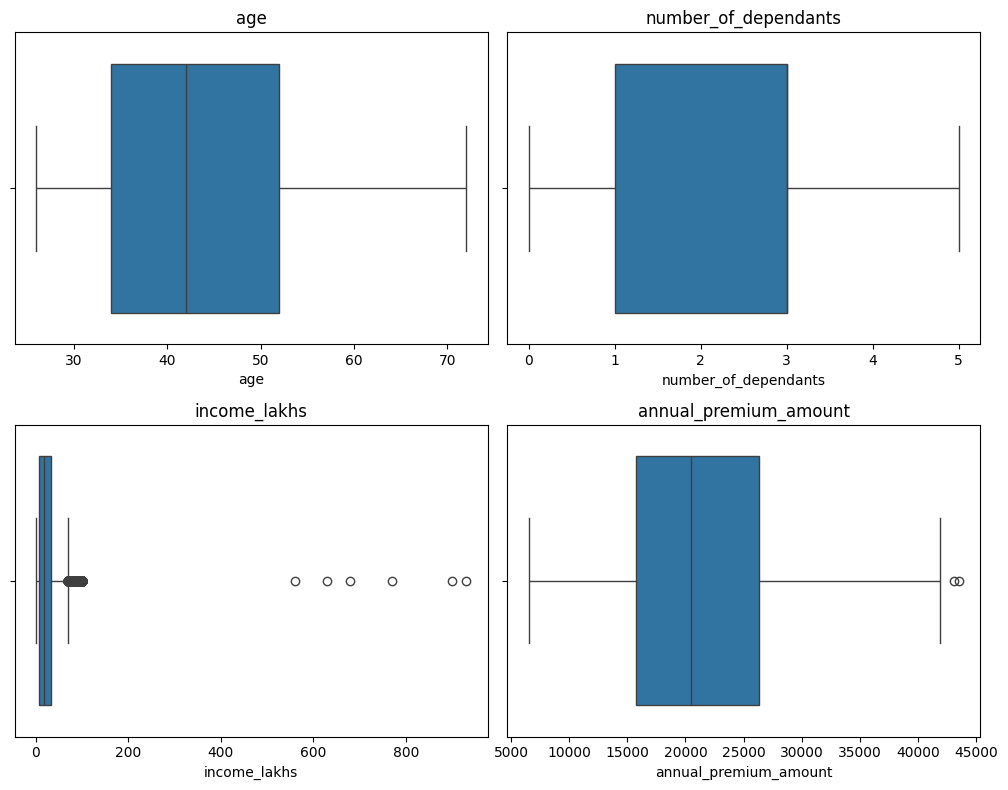

In [173]:
numeric_col = df.select_dtypes(include='number').columns
n_cols = 2  # Number of plots per row
n_rows = math.ceil(len(numeric_col) / n_cols)

plt.figure(figsize=(5 * n_cols, 4 * n_rows))

for i, col in enumerate(numeric_col, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

#### Histogram for Income column

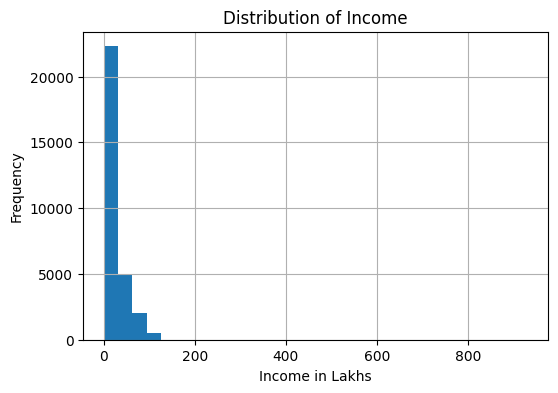

In [174]:
df['income_lakhs'].hist(bins=30, figsize=(6,4))
plt.title("Distribution of Income")
plt.xlabel("Income in Lakhs")
plt.ylabel("Frequency")
plt.show()

#### Outlier Removal using IQR

In [175]:
def iqr_cal(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound, upper_bound

In [176]:
upper, lower = iqr_cal('income_lakhs')
print(upper, lower)

-30.5 69.5


In [177]:
quantile_threshold = df.income_lakhs.quantile(0.999)
quantile_threshold

np.float64(100.0)

In [178]:
df = df[df['income_lakhs']<quantile_threshold]
df[df['income_lakhs']>100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount


#### Histogram for Numeric Columns

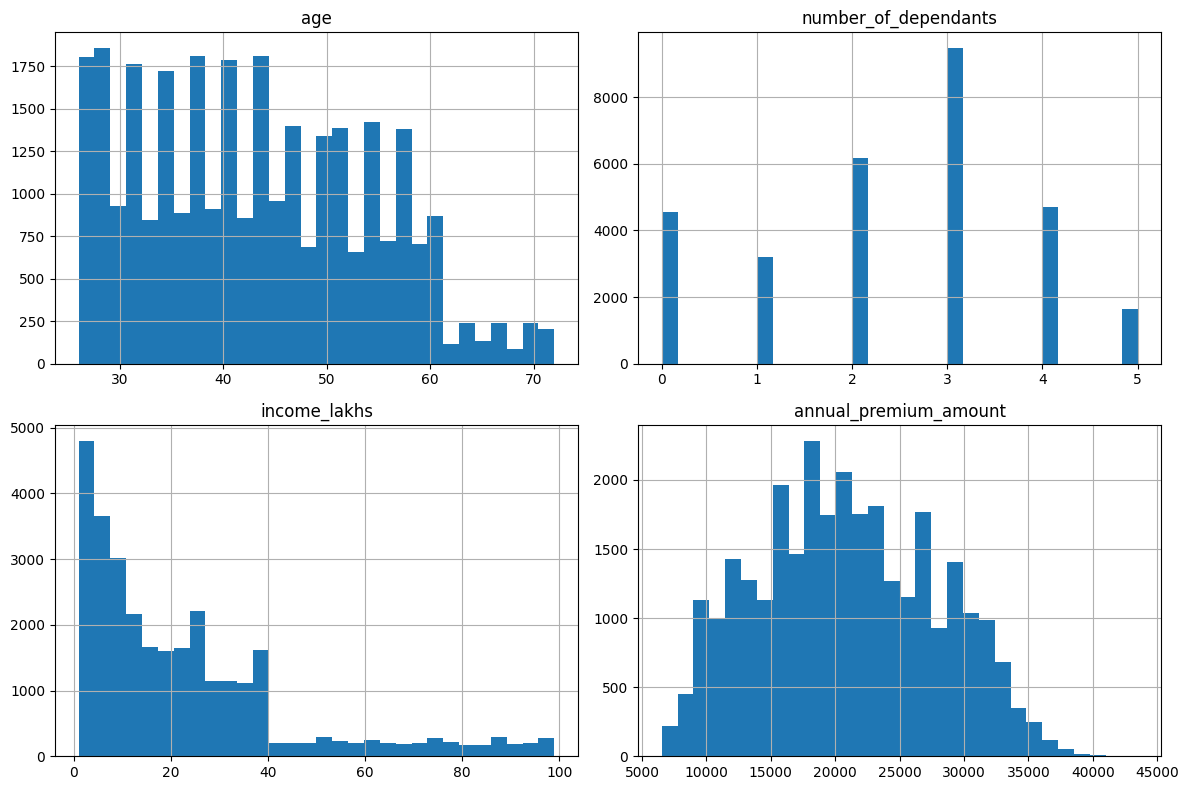

In [179]:
df.hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()

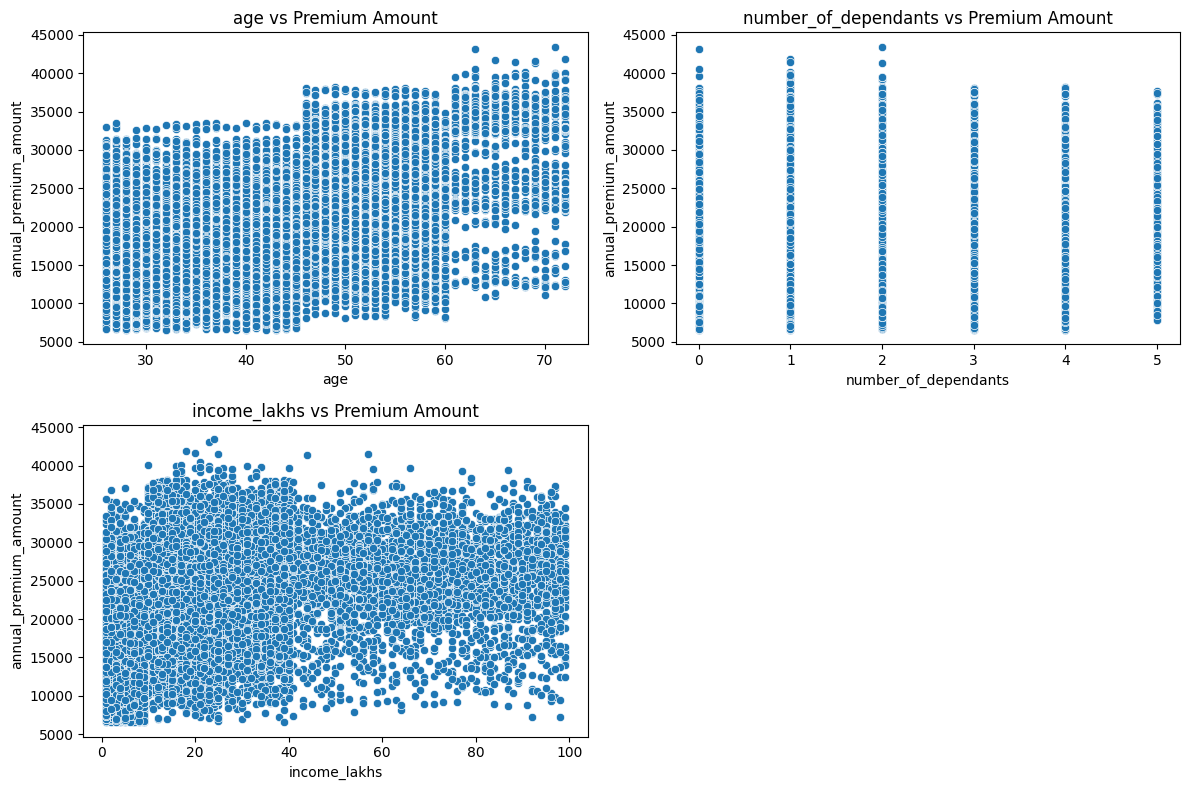

In [180]:
# num_col = numeric_col
num_col = numeric_col.drop('annual_premium_amount')  # remove target

n_cols = 2
n_rows = math.ceil(len(num_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_col):
    sns.scatterplot(x=df[col], y=df['annual_premium_amount'], ax=axes[i])
    axes[i].set_title(f"{col} vs Premium Amount")

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Outlier Removal in Categorical Column

In [181]:
cat_col = df.select_dtypes(include='object').columns
cat_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [182]:
for col in cat_col:
    print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status:['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status:['Salaried' 'Self-Employed' 'Freelancer']
income_level:['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history:['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan:['Bronze' 'Silver' 'Gold']


In [183]:
df['smoking_status'] = df['smoking_status'].replace(
    ['Smoking=0', 'Does Not Smoke', 'Not Smoking'],
    'No Smoking')

In [184]:
for col in cat_col:
    print(f"{col}:{df[col].unique()}")

gender:['Male' 'Female']
region:['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status:['Unmarried' 'Married']
bmi_category:['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status:['No Smoking' 'Regular' 'Occasional']
employment_status:['Salaried' 'Self-Employed' 'Freelancer']
income_level:['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history:['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan:['Bronze' 'Silver' 'Gold']


In [185]:
df['gender'].value_counts()

gender
Male      16334
Female    13420
Name: count, dtype: int64

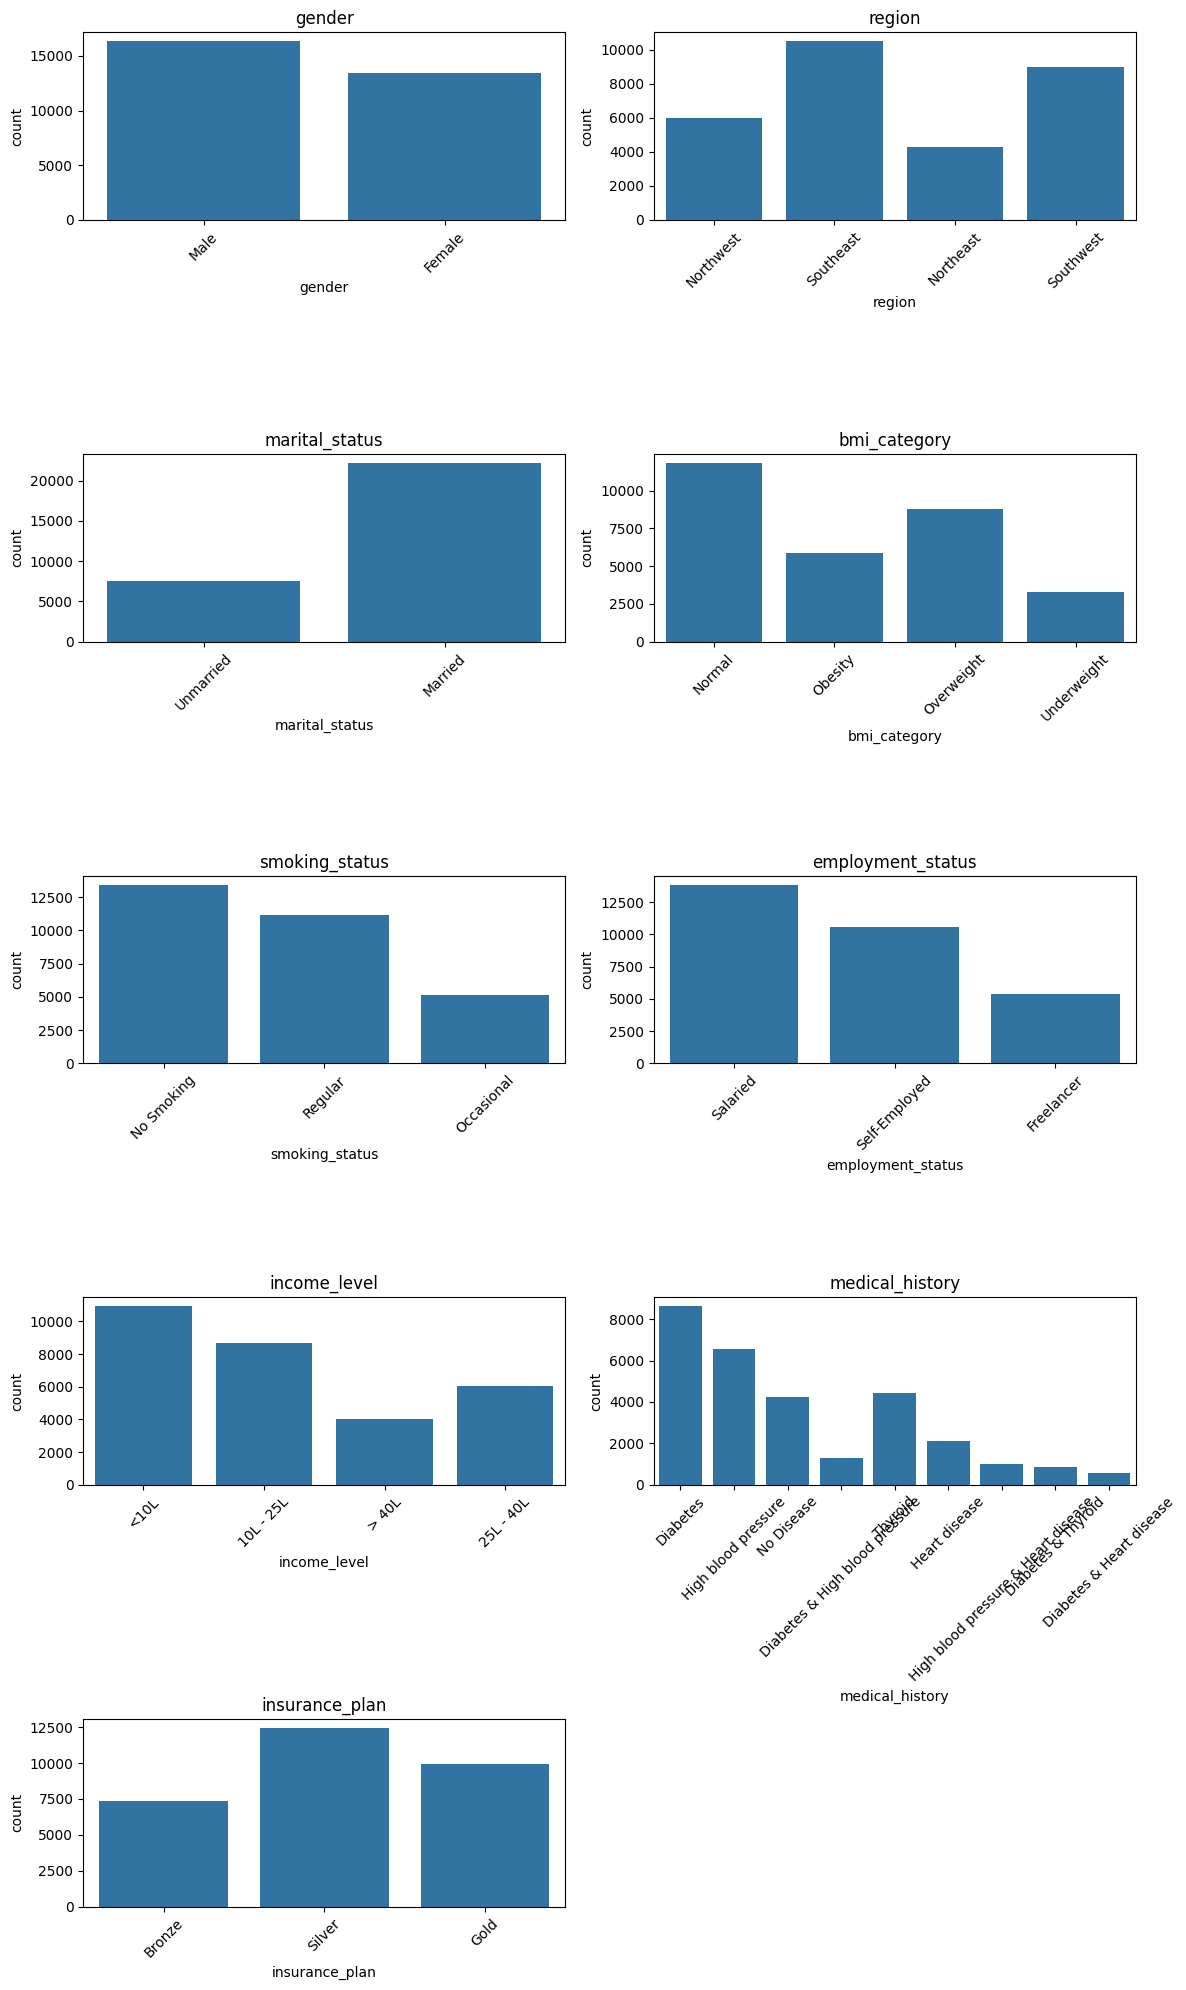

In [186]:
n_cols = 2
n_rows = math.ceil(len(cat_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_col):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Remove extra empty plots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Bi-Variate Analysis

In [187]:
pd.crosstab(df['income_level'], df['insurance_plan'])

insurance_plan,Bronze,Gold,Silver
income_level,,,
10L - 25L,799,3554,4354
25L - 40L,301,2631,3142
<10L,6054,527,4341
> 40L,211,3231,609


#### Feature Engineering

In [188]:
df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [189]:
risk_scores = {
    'diabetes':6,
    'heart disease':8,
    'high blood pressure':6,
    'no disease':0,
    'thyroid':5,
    'none':0
}

In [190]:
df[['disease1','disease2']] = df['medical_history'].str.split("&", expand=True).apply(lambda x:x.str.lower().str.strip())

In [191]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,None
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,diabetes,None


In [192]:
df['disease1'].fillna('none', inplace=True)
df['disease2'].fillna('none', inplace=True)
df.head()
invalid_rows = df[~df['disease1'].isin(risk_scores.keys())]
invalid_rows

C:\Users\yogesh\AppData\Local\Temp\ipykernel_16044\3574473948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['disease1'].fillna('none', inplace=True)
C:\Users\yogesh\AppData\Local\Temp\ipykernel_16044\3574473948.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2


In [193]:
df['total_risk_score'] = 0

for disease in ['disease1','disease2']:
    df['total_risk_score'] += df[disease].map(risk_scores)
max_score = df['total_risk_score'].max()
min_score = df['total_risk_score'].min()
df['normalized_risk_score'] = (df['total_risk_score'] - min_score )/(max_score - min_score)
df.sample(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
25318,72,Female,Southeast,Married,1,Normal,No Smoking,Self-Employed,10L - 25L,20,Diabetes,Gold,32809,diabetes,none,6,0.428571
13419,70,Male,Southwest,Married,1,Normal,No Smoking,Self-Employed,25L - 40L,36,High blood pressure,Gold,32210,high blood pressure,none,6,0.428571
725,41,Male,Southeast,Married,2,Underweight,No Smoking,Salaried,10L - 25L,19,No Disease,Silver,13881,no disease,none,0,0.000000
27302,33,Male,Southeast,Unmarried,1,Underweight,Regular,Self-Employed,25L - 40L,38,No Disease,Silver,17173,no disease,none,0,0.000000
25354,56,Male,Northwest,Married,3,Overweight,Regular,Salaried,<10L,9,Thyroid,Silver,23042,thyroid,none,5,0.357143


In [194]:
df.insurance_plan.unique()

array(['Bronze', 'Silver', 'Gold'], dtype=object)

In [195]:
df['insurance_plan'] = df['insurance_plan'].map({'Bronze':1, 'Silver':2, 'Gold':3})
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,1,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,1,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,2,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,3,20303,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,1,15610,diabetes,none,6,0.428571


In [196]:
df.insurance_plan.unique()

array([1, 2, 3])

In [197]:
df['income_level'].unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [198]:
df['income_level'] = df['income_level'].map({'<10L':1, '10L - 25L':2, '> 40L':4, '25L - 40L':3})
df.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,Diabetes,1,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,1,6,Diabetes,1,16339,diabetes,none,6,0.428571


In [199]:
df['income_level'].unique()

array([1, 2, 4, 3])

In [200]:
nominal_cols = ['gender','region','marital_status','bmi_category','smoking_status','employment_status']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True, dtype=int)
df.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,diabetes,none,6,...,0,0,0,1,0,0,1,0,0,1


In [201]:
df = df.drop(['medical_history','disease1','disease2','total_risk_score'],axis=1)

In [202]:
df.head(2)

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0


#### Correlation

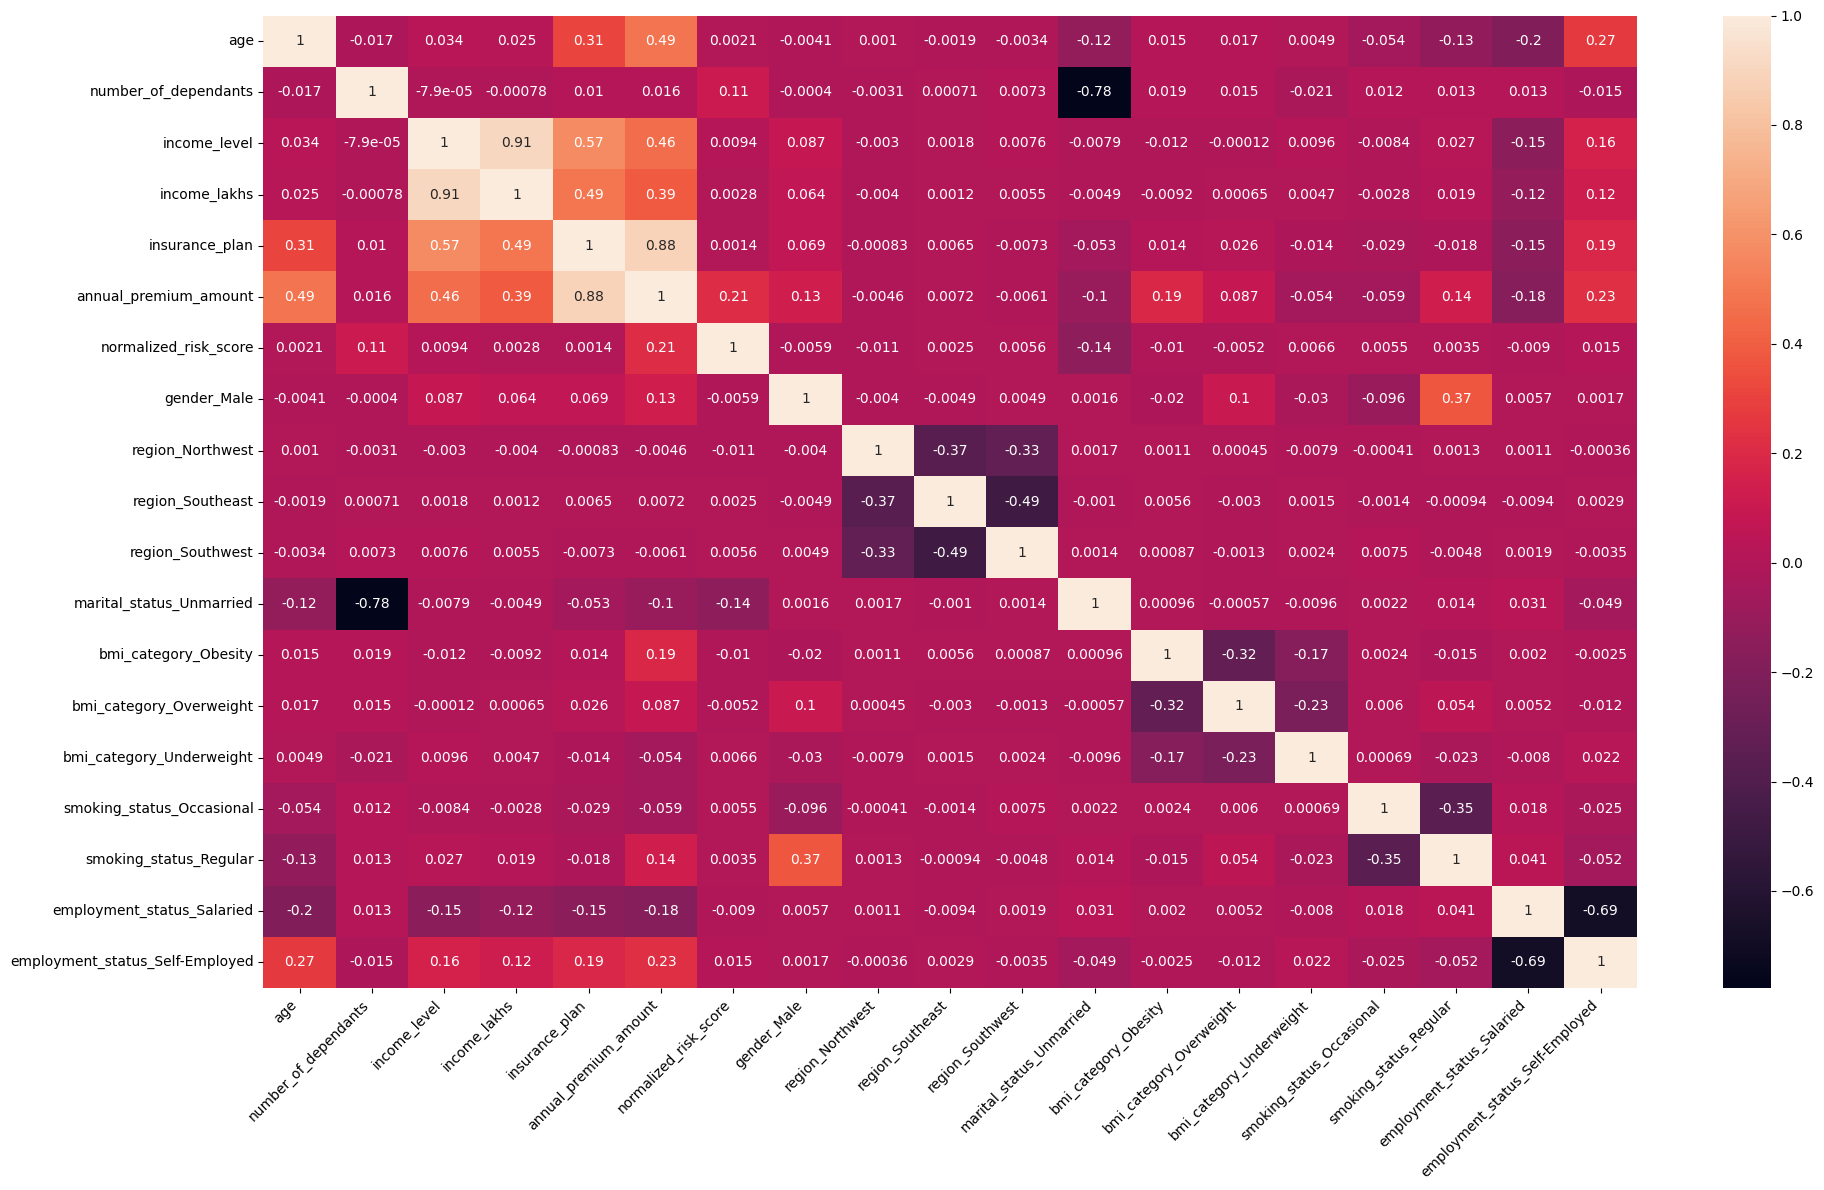

In [203]:
cm = df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [204]:
df.columns

Index(['age', 'number_of_dependants', 'income_level', 'income_lakhs',
       'insurance_plan', 'annual_premium_amount', 'normalized_risk_score',
       'gender_Male', 'region_Northwest', 'region_Southeast',
       'region_Southwest', 'marital_status_Unmarried', 'bmi_category_Obesity',
       'bmi_category_Overweight', 'bmi_category_Underweight',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

In [205]:
X = df.drop('annual_premium_amount', axis=1)
y = df['annual_premium_amount']
cols_to_scale = ['age','income_level','income_lakhs','insurance_plan','number_of_dependants']
scaler = MinMaxScaler()

X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.051020,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.051020,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.193878,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.775510,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.132653,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


In [206]:
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000,29754.000000
mean,0.371683,0.477536,0.369788,0.225009,0.543322,0.426404,0.548968,0.200746,0.352726,0.301875,0.253378,0.196982,0.294918,0.110103,0.173254,0.374605,0.466189,0.354272
std,0.240080,0.284145,0.350221,0.226314,0.378885,0.240132,0.497605,0.400565,0.477826,0.459079,0.434953,0.397725,0.456014,0.313023,0.378473,0.484029,0.498864,0.478300
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.200000,0.000000,0.061224,0.500000,0.357143,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.347826,0.600000,0.333333,0.163265,0.500000,0.428571,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.565217,0.600000,0.666667,0.316327,1.000000,0.428571,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


#### Calculating VIF

In [207]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [208]:
calculate_vif(X)

,Column,VIF
0,age,3.924740
1,number_of_dependants,6.276728
2,income_level,14.063416
3,income_lakhs,11.408527
4,insurance_plan,5.260860
5,normalized_risk_score,3.809601
6,gender_Male,2.598259
7,region_Northwest,2.123193
8,region_Southeast,2.979784
9,region_Southwest,2.708419


In [209]:
calculate_vif(X.drop('income_level',axis=1))

,Column,VIF
0,age,3.865086
1,number_of_dependants,6.276116
2,income_lakhs,2.690925
3,insurance_plan,4.571804
4,normalized_risk_score,3.807473
5,gender_Male,2.590560
6,region_Northwest,2.122529
7,region_Southeast,2.978859
8,region_Southwest,2.706927
9,marital_status_Unmarried,2.345161


In [210]:
X_reduced = X.drop('income_level',axis=1)
X_reduced.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.051020,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.051020,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.193878,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,0.775510,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.132653,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


#### Model Training

In [211]:
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y, test_size=0.3, random_state=10)

print("X train: ",X_train.shape)
print("X test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

X train:  (20827, 17)
X test:  (8927, 17)
y train:  (20827,)
y test:  (8927,)


In [212]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
r2_train = model_lr.score(X_train, y_train)
# y_pred = model_lr.predict(X_test)
r2_test = model_lr.score(X_test, y_test)

r2_test, r2_train

(0.952982332468962, 0.9537747062669479)

In [213]:
model_lr.intercept_

np.float64(5934.164822853161)

In [214]:
model_lr.coef_

array([ 6.96353453e+03, -1.31279216e+03, -7.52016885e+02,  1.48577428e+04,
        6.02525138e+03,  5.29109471e+01, -4.19355491e+01, -4.28778476e+00,
       -5.58970719e+00, -7.20469122e+02,  3.95823598e+03,  2.01694333e+03,
        6.05139302e+02,  8.29393700e+02,  2.80100338e+03, -8.17751554e+01,
        2.46364123e+02])

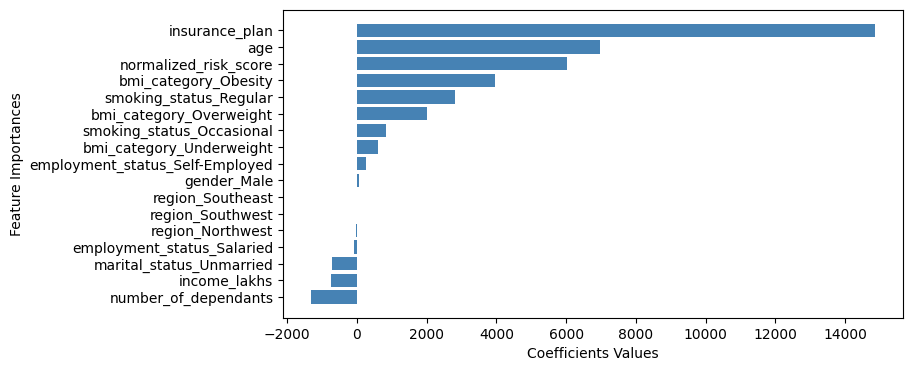

In [215]:
feature_importances = model_lr.coef_
coef_df = pd.DataFrame(feature_importances, index=X_test.columns, columns=['Coefficients'])
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficients Values')
plt.ylabel('Feature Importances')
plt.show()

In [216]:
model_rg = Ridge()
model_rg.fit(X_train, y_train)
r2_train = model_rg.score(X_train, y_train)
# y_pred = model_rg.predict(X_test)
r2_test = model_rg.score(X_test, y_test)

r2_test, r2_train

(0.9529834791901383, 0.9537745356368772)

In [217]:
from xgboost import XGBRegressor

In [218]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train, y_train)
r2_train = model_xgb.score(X_train, y_train)
y_pred = model_xgb.predict(X_test)
r2_test = model_xgb.score(X_test, y_test)

r2_test, r2_train

(0.9980076551437378, 0.9986194968223572)

In [219]:
mse_xgb = mean_squared_error(y_test, y_pred)
rmse_xgb = np.sqrt(mse_xgb)
print(f"XGBoost Regression ==> MSE: {mse_xgb} RMSE: {rmse_xgb}")

XGBoost Regression ==> MSE: 96006.8515625 RMSE: 309.8497241607615


In [220]:
model_xgb = XGBRegressor()
param_grid = {
    'n_estimators': [20,40,50],
    'learning_rate': [0.01,0.1,0.2],
    'max_depth':[3,4,5]
}
random_search = RandomizedSearchCV(model_xgb, param_grid, n_iter=10, cv=3, scoring='r2')
random_search.fit(X_train, y_train)
random_search.best_score_

np.float64(0.9953563610712687)

In [221]:
best_model = random_search.best_estimator_

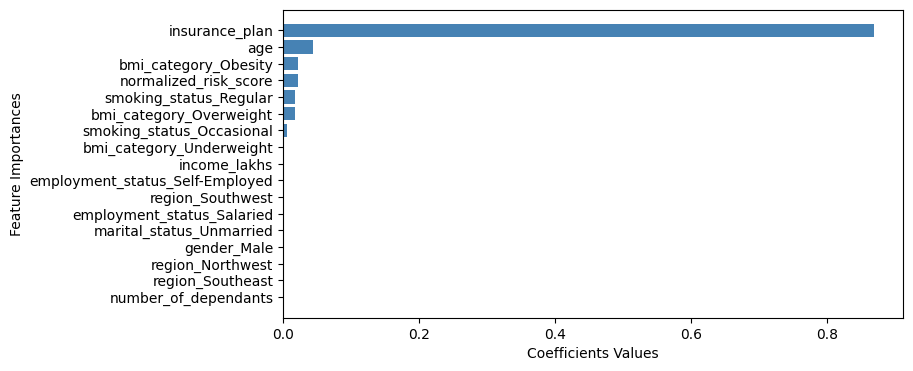

In [222]:
feature_importances = best_model.feature_importances_
coef_df = pd.DataFrame(feature_importances, index=X_test.columns, columns=['Coefficients'])
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

plt.figure(figsize=(8,4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficients Values')
plt.ylabel('Feature Importances')
plt.show()

#### Error Analysis

In [223]:
y_pred = best_model.predict(X_test)

residuals = y_pred - y_test
residuals_pct = residuals*100/y_test
results_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})
results_df.head()

,actual,predicted,diff,diff_pct
18272,12370,11993.194336,-376.805664,-3.046125
24662,11253,12197.748047,944.748047,8.395522
1789,30688,30105.412109,-582.587891,-1.898422
29834,22139,22402.042969,263.042969,1.188143
1478,27040,27432.683594,392.683594,1.452232


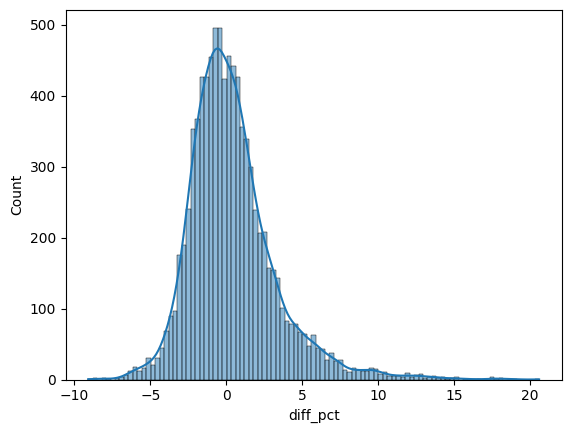

In [224]:
sns.histplot(results_df['diff_pct'],kde=True)
plt.show()

In [225]:
extreme_error_threshold = 10
extreme_results_df = results_df[np.abs(results_df.diff_pct)>extreme_error_threshold]
extreme_results_df.shape


(98, 4)

In [226]:
extreme_error_pct = extreme_results_df.shape[0]*100/results_df.shape[0]
extreme_error_pct

1.0977932116052425

In [235]:
results_df[np.abs(results_df.diff_pct)>10].sort_values('diff_pct', ascending=False)

,actual,predicted,diff,diff_pct
7547,6538,7884.342285,1346.342285,20.592571
15413,6625,7884.342285,1259.342285,19.008940
8506,6640,7884.342285,1244.342285,18.740095
29258,6673,7884.342285,1211.342285,18.152889
8176,6676,7884.342285,1208.342285,18.099795
...,...,...,...,...
9820,7246,7982.145020,736.145020,10.159330
27141,10230,11268.150391,1038.150391,10.148098
9634,11079,12197.748047,1118.748047,10.097915
4919,10235,11268.150391,1033.150391,10.094288


In [228]:
X_test.index

Index([18272, 24662,  1789, 29834,  1478, 17822, 25874, 29750,  6163,  4487,
       ...
       28539,  8610, 21146, 26201, 19137,  8857,  3726,  6030, 25410, 13716],
      dtype='int64', length=8927)

In [229]:
extreme_results_df.index

Index([ 6163, 14728,  1549,  9756,  3775, 25022,  2558, 14650, 29123, 11014,
       12026, 29165,  9698,  6369,  5682, 23578, 26347,  1294, 13744,  3979,
       13973,  7893, 23882, 22941,  7547, 11895, 27141,  9634, 11292, 21299,
       27989, 13903, 24148, 21137,   551,   252,  5731,  9285,  2231, 19210,
       14182, 24145, 18838, 15462, 21141, 29258,   885, 20609, 15581, 16376,
       23378,  8506,  1010, 20383, 21251, 29269,   542,  4557, 25617,  7058,
         809, 15413,  4322, 21540, 28107,  9820, 22432,  6661,  2438, 16570,
       22147,  8176,  7028,  6673, 11817,  3319, 10741,  3416, 29657,  1648,
       25207,  9150,  7151, 16476, 12276, 12939,  8835, 11231, 12746, 23883,
        6236,  2582,  3325,  4655,  5179, 14521,  4919, 12662],
      dtype='int64')

In [230]:
extreme_error_df = X_test.loc[extreme_results_df.index]
extreme_error_df.head()

,age,number_of_dependants,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
6163,0.217391,0.0,0.000000,0.0,0.000000,0,0,0,1,1,0,0,0,0,0,0,0
14728,0.413043,0.0,0.061224,0.0,0.000000,1,1,0,0,1,0,0,0,0,0,0,1
1549,0.065217,0.8,0.020408,0.0,0.428571,1,0,1,0,0,0,0,0,0,0,1,0
9756,0.326087,0.4,0.061224,0.0,0.000000,0,1,0,0,0,0,0,0,0,0,1,0
3775,0.239130,0.6,0.081633,0.0,0.428571,1,0,1,0,0,0,0,0,0,0,1,0


In [231]:
extreme_error_df['income_level']=-1

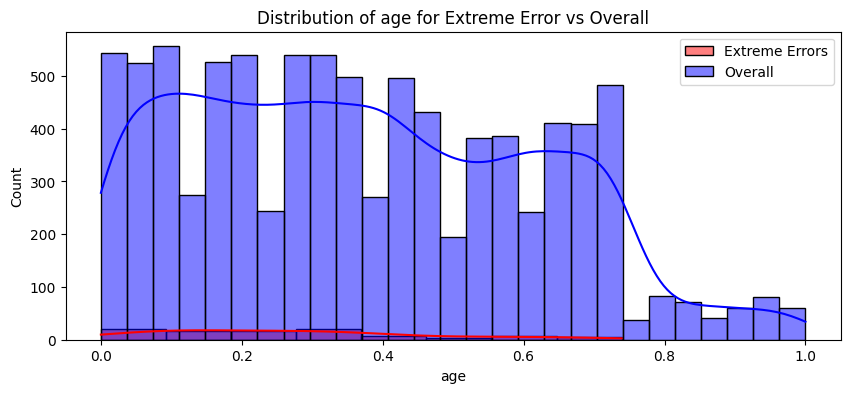

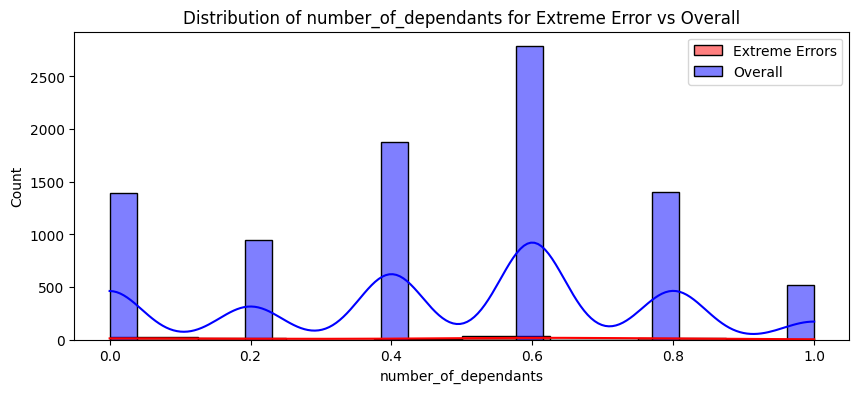

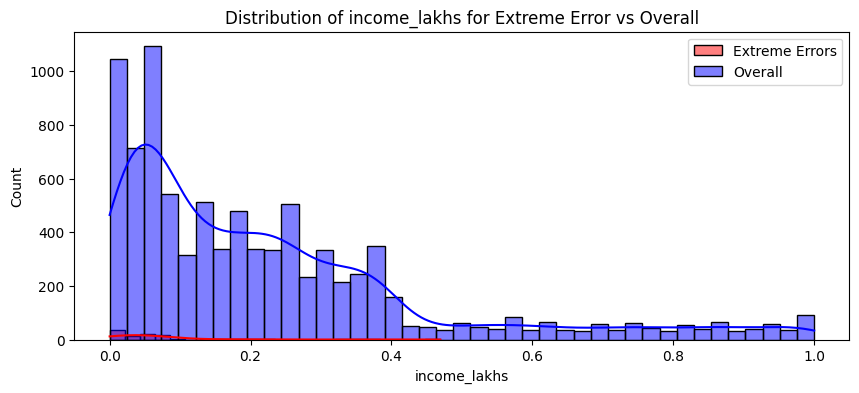

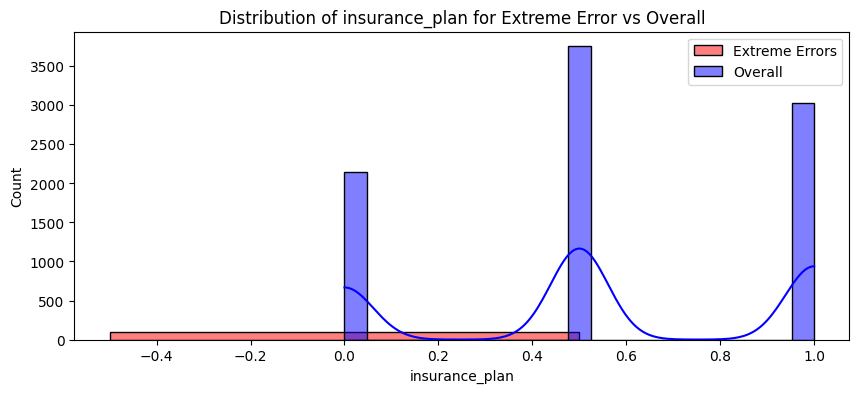

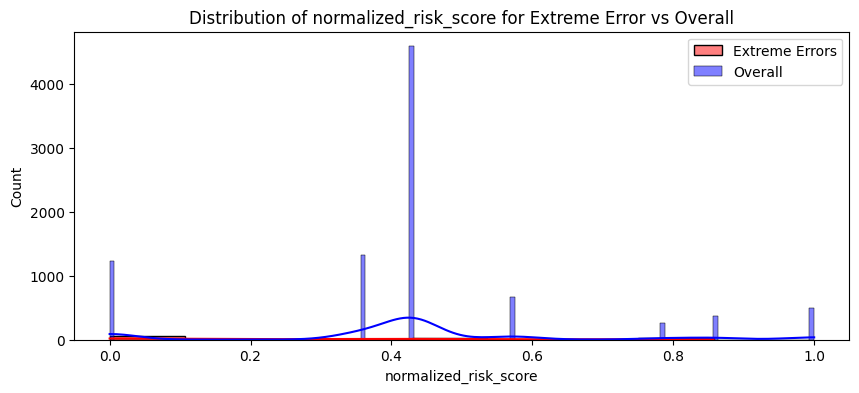

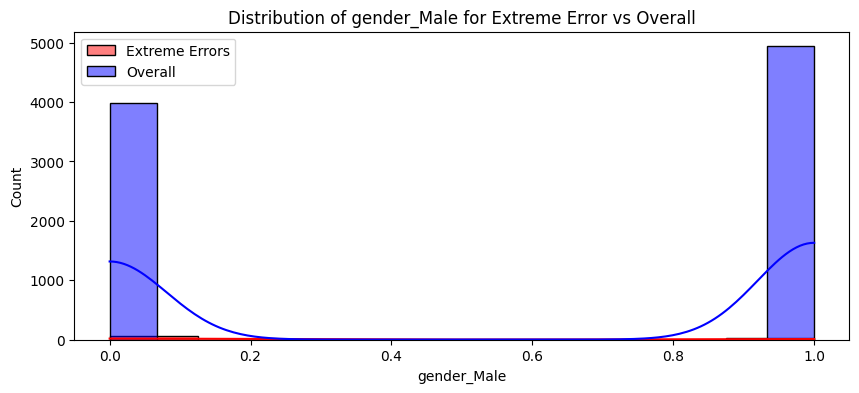

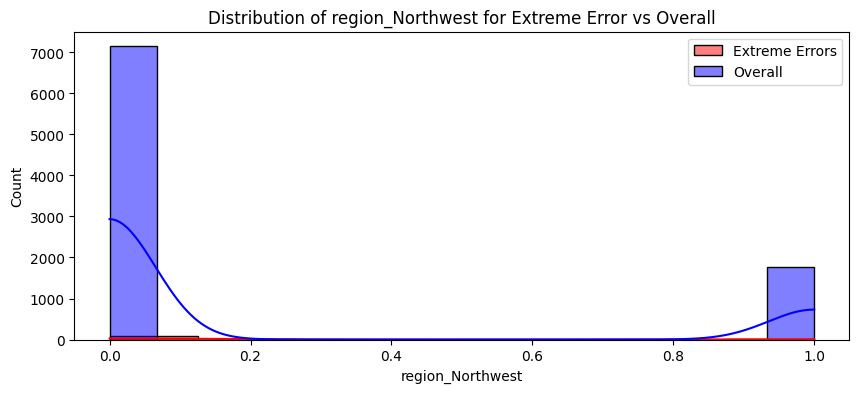

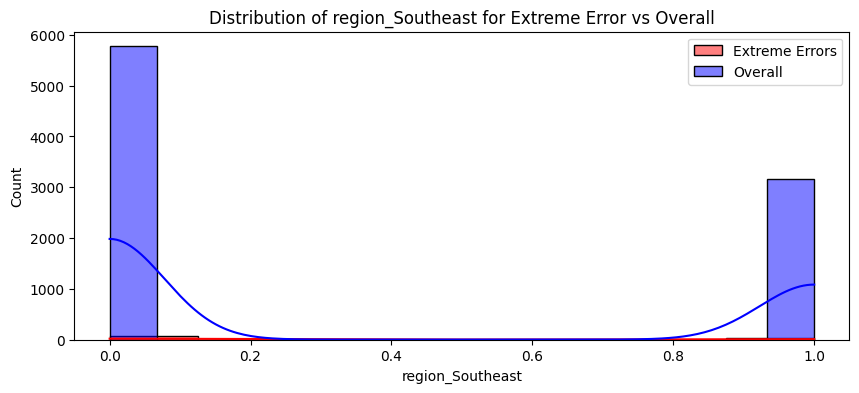

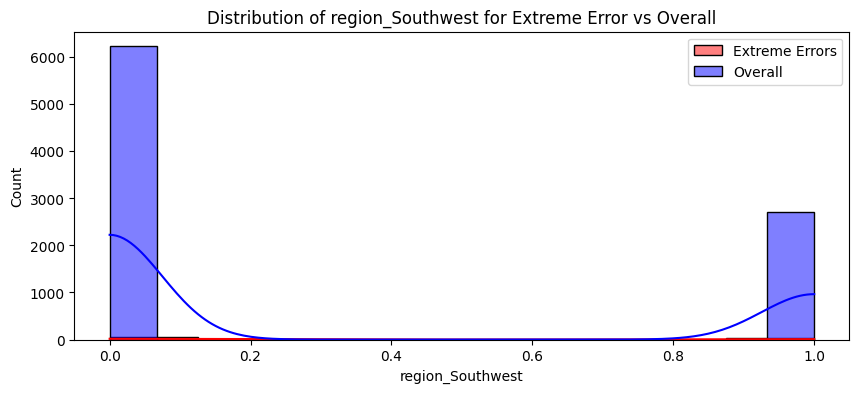

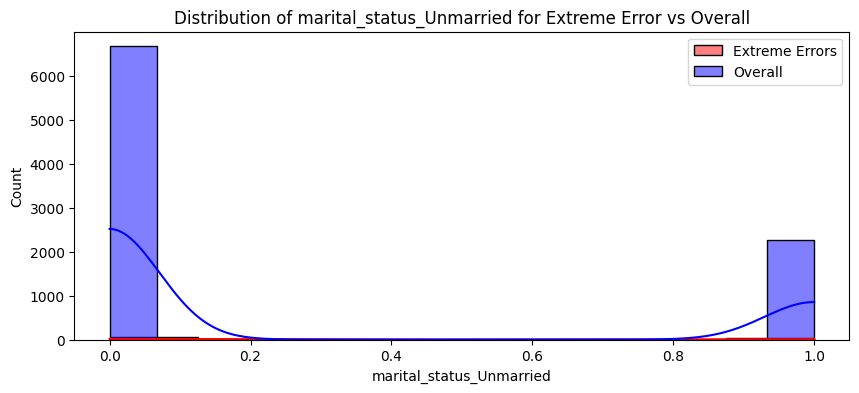

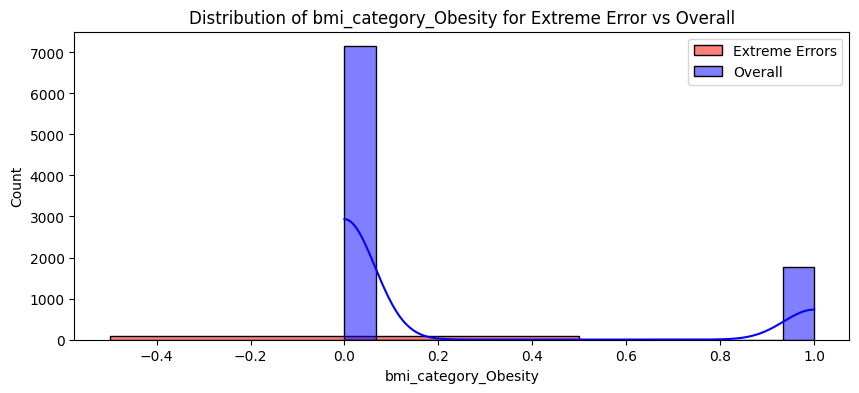

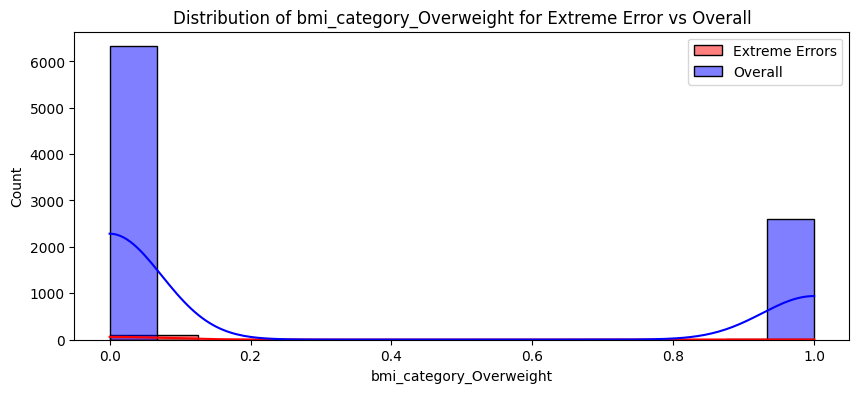

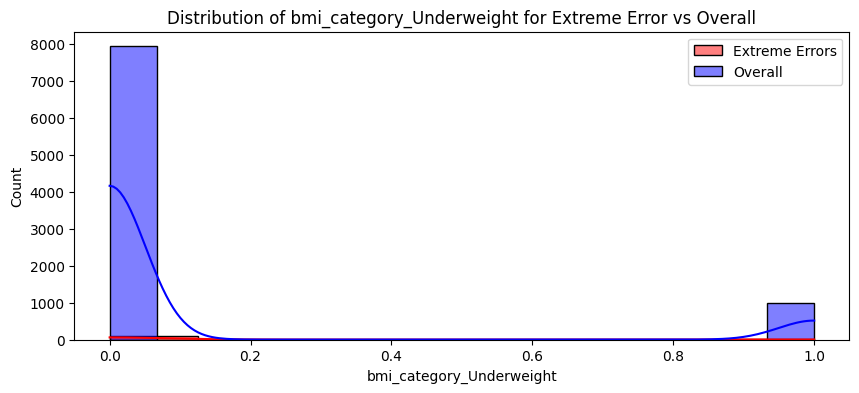

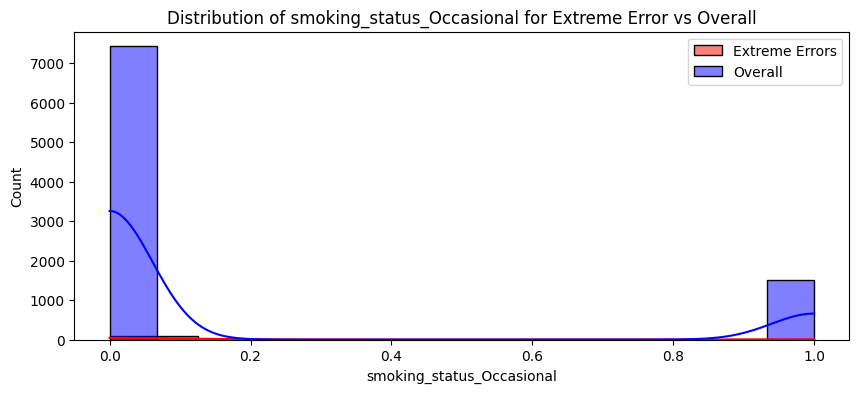

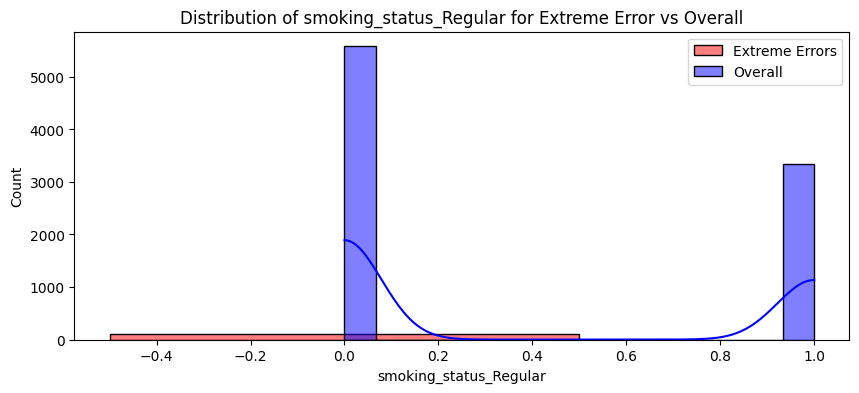

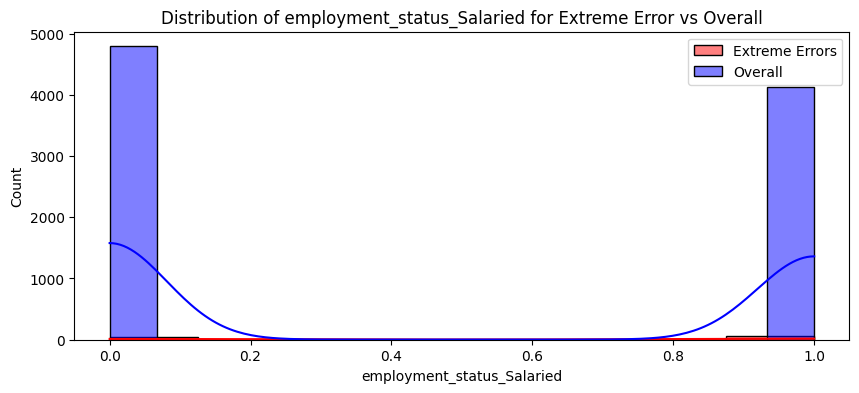

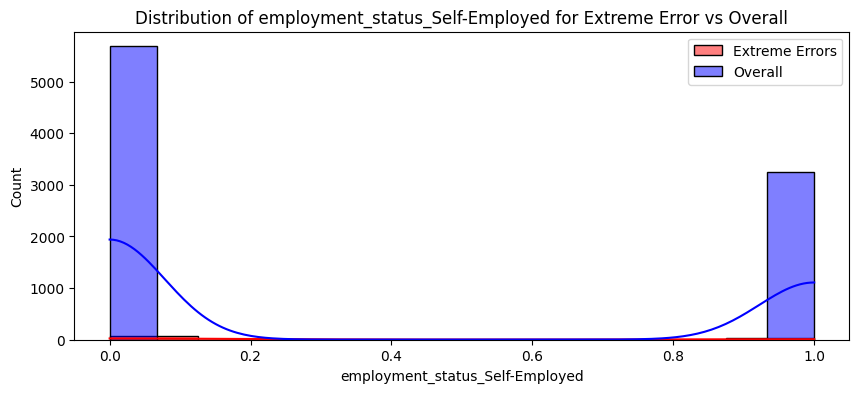

In [232]:
for feature in X_test.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(extreme_error_df[feature],color='red',label='Extreme Errors',kde=True)
    sns.histplot(X_test[feature],color='blue', label='Overall',alpha=0.5,kde=True)
    plt.legend()
    plt.title(f"Distribution of {feature} for Extreme Error vs Overall")
    plt.show()

<Axes: xlabel='age', ylabel='Count'>

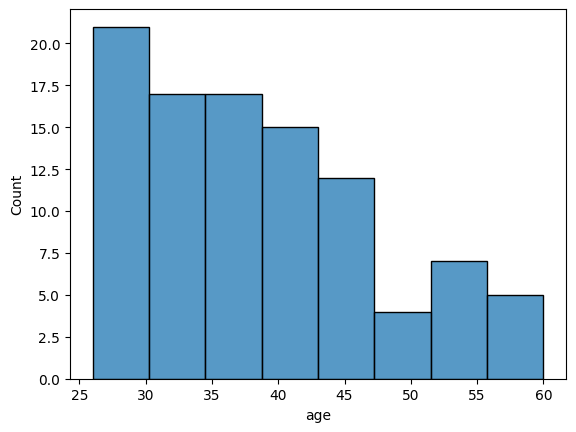

In [233]:
df_reversed = pd.DataFrame()
df_reversed[cols_to_scale] = scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed
sns.histplot(df_reversed['age'])

In [234]:
df_reversed['age'].quantile(0.99)

np.float64(59.03)